In [41]:
import pandas as pd
import numpy as np
df=pd.read_csv('post natal data.csv')
df

,Timestamp,Age,Feeling sad or Tearful,Irritable towards baby & partner,Trouble sleeping at night,Problems concentrating or making decision,Overeating or loss of appetite,Feeling anxious,Feeling of guilt,Problems of bonding with baby,Suicide attempt
0,6/14/2022 20:02,35-40,Yes,Yes,Two or more days a week,Yes,Yes,Yes,No,Yes,Yes
1,6/14/2022 20:03,40-45,Yes,No,No,Yes,Yes,No,Yes,Yes,No
2,6/14/2022 20:04,35-40,Yes,No,Yes,Yes,Yes,Yes,No,Sometimes,No
3,6/14/2022 20:05,35-40,Yes,Yes,Yes,Yes,No,Yes,Maybe,No,No
4,6/14/2022 20:06,40-45,Yes,No,Two or more days a week,Yes,No,Yes,No,Yes,No
...,...,...,...,...,...,...,...,...,...,...,...
1498,6/15/2022 0:35,30-35,Yes,No,Two or more days a week,No,No,Yes,Maybe,Sometimes,No
1499,6/15/2022 0:35,25-30,Sometimes,No,No,Often,No,Yes,Maybe,Yes,No
1500,6/15/2022 0:35,25-30,No,Sometimes,Two or more days a week,No,No,No,Yes,No,Not interested to say
1501,6/15/2022 0:36,25-30,No,Sometimes,Yes,Often,No,Yes,No,No,No


In [2]:
import pandas as pd
from ydata_profiling import ProfileReport

In [3]:
profile = ProfileReport(df, title="Depression Data Profiling Report", explorative=True)

In [4]:
profile

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 11/11 [00:01<00:00,  6.22it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [42]:
df.head(1)

,Timestamp,Age,Feeling sad or Tearful,Irritable towards baby & partner,Trouble sleeping at night,Problems concentrating or making decision,Overeating or loss of appetite,Feeling anxious,Feeling of guilt,Problems of bonding with baby,Suicide attempt
0,6/14/2022 20:02,35-40,Yes,Yes,Two or more days a week,Yes,Yes,Yes,No,Yes,Yes


# Drop the unnecessry column

In [43]:
df=df.drop(columns=['Timestamp'])


In [44]:
df.head()

,Age,Feeling sad or Tearful,Irritable towards baby & partner,Trouble sleeping at night,Problems concentrating or making decision,Overeating or loss of appetite,Feeling anxious,Feeling of guilt,Problems of bonding with baby,Suicide attempt
0,35-40,Yes,Yes,Two or more days a week,Yes,Yes,Yes,No,Yes,Yes
1,40-45,Yes,No,No,Yes,Yes,No,Yes,Yes,No
2,35-40,Yes,No,Yes,Yes,Yes,Yes,No,Sometimes,No
3,35-40,Yes,Yes,Yes,Yes,No,Yes,Maybe,No,No
4,40-45,Yes,No,Two or more days a week,Yes,No,Yes,No,Yes,No


In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1503 entries, 0 to 1502
Data columns (total 10 columns):
 #   Column                                     Non-Null Count  Dtype 
---  ------                                     --------------  ----- 
 0   Age                                        1503 non-null   object
 1   Feeling sad or Tearful                     1503 non-null   object
 2   Irritable towards baby & partner           1497 non-null   object
 3   Trouble sleeping at night                  1503 non-null   object
 4   Problems concentrating or making decision  1491 non-null   object
 5   Overeating or loss of appetite             1503 non-null   object
 6   Feeling anxious                            1503 non-null   object
 7   Feeling of guilt                           1494 non-null   object
 8   Problems of bonding with baby              1503 non-null   object
 9   Suicide attempt                            1503 non-null   object
dtypes: object(10)
memory usage: 117.6+ K

# Find Missing value

In [46]:
df.isnull().sum()

Age                                           0
Feeling sad or Tearful                        0
Irritable towards baby & partner              6
Trouble sleeping at night                     0
Problems concentrating or making decision    12
Overeating or loss of appetite                0
Feeling anxious                               0
Feeling of guilt                              9
Problems of bonding with baby                 0
Suicide attempt                               0
dtype: int64

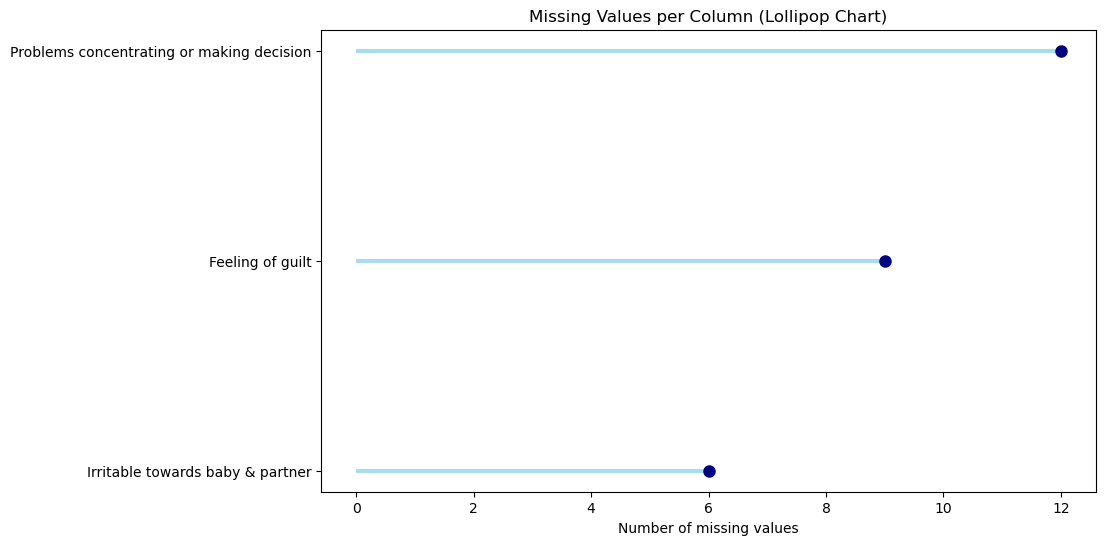

In [50]:
import matplotlib.pyplot as plt
import numpy as np

# Count missing values per column
missing_counts = df.isnull().sum()
missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=True)

plt.figure(figsize=(10,6))
plt.hlines(y=missing_counts.index, xmin=0, xmax=missing_counts.values, color='skyblue', alpha=0.7, linewidth=3)
plt.plot(missing_counts.values, missing_counts.index, "o", markersize=8, color='navy')
plt.xlabel("Number of missing values")
plt.title("Missing Values per Column (Lollipop Chart)")
plt.show()


In [18]:
df.columns

Index(['Age', 'Feeling sad or Tearful', 'Irritable towards baby & partner',
       'Trouble sleeping at night',
       'Problems concentrating or making decision',
       'Overeating or loss of appetite', 'Feeling anxious', 'Feeling of guilt',
       'Problems of bonding with baby', 'Suicide attempt'],
      dtype='object')

In [51]:
cols = [
    'Age', 
    'Feeling sad or Tearful',
    'Irritable towards baby & partner',
    'Trouble sleeping at night',
    'Problems concentrating or making decision',
    'Overeating or loss of appetite',
    'Feeling anxious',
    'Feeling of guilt',
    'Problems of bonding with baby',
    'Suicide attempt'
]

for col in cols:
    print(f"\n--- {col} ---")
    print(df[col].unique())



--- Age ---
['35-40' '40-45' '30-35' '45-50' '25-30']

--- Feeling sad or Tearful ---
['Yes' 'No' 'Sometimes']

--- Irritable towards baby & partner ---
['Yes' 'No' 'Sometimes' nan]

--- Trouble sleeping at night ---
['Two or more days a week' 'No' 'Yes']

--- Problems concentrating or making decision ---
['Yes' 'No' 'Often' nan]

--- Overeating or loss of appetite ---
['Yes' 'No' 'Not at all']

--- Feeling anxious ---
['Yes' 'No']

--- Feeling of guilt ---
['No' 'Yes' 'Maybe' nan]

--- Problems of bonding with baby ---
['Yes' 'Sometimes' 'No']

--- Suicide attempt ---
['Yes' 'No' 'Not interested to say']


In [22]:
expected_values = {
    'Age': set(range(18, 60)),  # example: ages 18–59
    'Feeling sad or Tearful': {'Yes', 'No','Sometimes'},
    'Irritable towards baby & partner': {'Yes', 'No','Sometimes'},
    'Trouble sleeping at night': {'Yes', 'No','Two or more days a week'},
    'Problems concentrating or making decision': {'Yes', 'No','Often'},
    'Overeating or loss of appetite': {'Yes', 'No','Not at all'},
    'Feeling anxious': {'Yes', 'No'},
    'Feeling of guilt': {'Yes', 'No','Maybe'},
    'Problems of bonding with baby': {'Yes', 'No','Sometimes'},
    'Suicide attempt': {'Yes', 'No','Not interested to say'}
}


In [23]:
for col, expected in expected_values.items():
    actual = set(df[col].dropna().unique())
    unexpected = actual - expected
    if unexpected:
        print(f"\n⚠️ Column '{col}' has unexpected values: {unexpected}")
    else:
        print(f"✅ Column '{col}' is clean (only expected values found).")



⚠️ Column 'Age' has unexpected values: {'45-50', '25-30', '30-35', '40-45', '35-40'}
✅ Column 'Feeling sad or Tearful' is clean (only expected values found).
✅ Column 'Irritable towards baby & partner' is clean (only expected values found).
✅ Column 'Trouble sleeping at night' is clean (only expected values found).
✅ Column 'Problems concentrating or making decision' is clean (only expected values found).
✅ Column 'Overeating or loss of appetite' is clean (only expected values found).
✅ Column 'Feeling anxious' is clean (only expected values found).
✅ Column 'Feeling of guilt' is clean (only expected values found).
✅ Column 'Problems of bonding with baby' is clean (only expected values found).
✅ Column 'Suicide attempt' is clean (only expected values found).


# Irritable towards baby & partner have missing valu

In [52]:
df['Irritable towards baby & partner'].isnull().sum()

6

In [53]:
df['Irritable towards baby & partner'].unique()

array(['Yes', 'No', 'Sometimes', nan], dtype=object)

# Fill NaN with Mode


In [54]:
df['Irritable towards baby & partner'].fillna(
    df['Irritable towards baby & partner'].mode()[0],
    inplace=True
)


C:\Users\estya\AppData\Local\Temp\ipykernel_20928\123690031.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Irritable towards baby & partner'].fillna(


# After mode

In [55]:
df['Irritable towards baby & partner'].isnull().sum()

0

# Remove rows with NaN in this column

In [ ]:
df['Irritable towards baby & partner'].isnull().sum()


# " Problems concentrating or making decision " have a msisiing valu

In [56]:

df['Problems concentrating or making decision'].isnull().sum()

12

In [57]:
df['Problems concentrating or making decision'] = df['Problems concentrating or making decision'].fillna(
    df['Problems concentrating or making decision'].mode()[0]
)


In [58]:
df['Problems concentrating or making decision'].isnull().sum()

0

# " Feeling of guilt  have missing value"

In [59]:
df['Feeling of guilt'].isnull().sum()

9

In [60]:
df['Feeling of guilt'] = df['Feeling of guilt'].fillna(
    df['Feeling of guilt'].mode()[0]
)

In [61]:
df['Feeling of guilt'].isnull().sum()

0

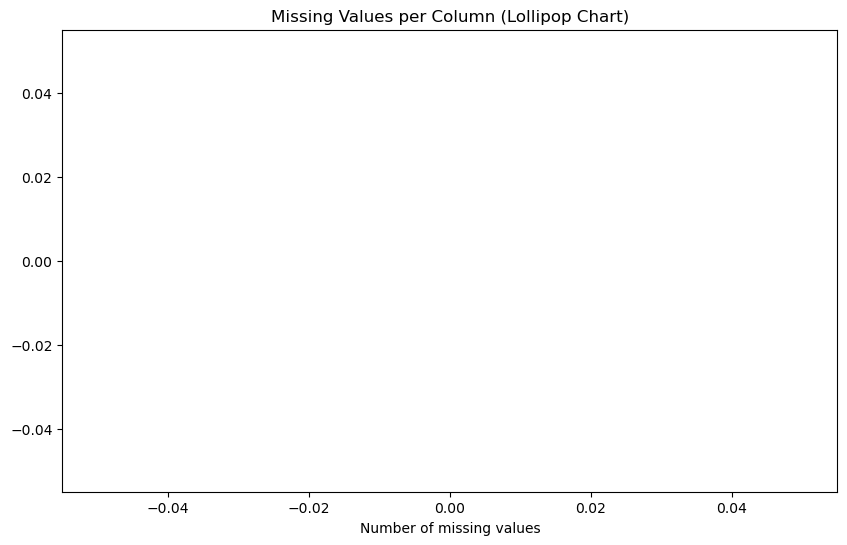

In [62]:
import matplotlib.pyplot as plt
import numpy as np

# Count missing values per column
missing_counts = df.isnull().sum()
missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=True)

plt.figure(figsize=(10,6))
plt.hlines(y=missing_counts.index, xmin=0, xmax=missing_counts.values, color='skyblue', alpha=0.7, linewidth=3)
plt.plot(missing_counts.values, missing_counts.index, "o", markersize=8, color='navy')
plt.xlabel("Number of missing values")
plt.title("Missing Values per Column (Lollipop Chart)")
plt.show()


In [66]:
df_encoded = df.copy()  # Make a copy of your original DataFrame

mapping = {
    'Feeling sad or Tearful': {'No': 0, 'Sometimes': 1, 'Yes': 2},
    'Irritable towards baby & partner': {'No': 0, 'Sometimes': 1, 'Yes': 2},
    'Trouble sleeping at night': {'No': 0, 'Two or more days a week': 1, 'Yes': 2},
    'Problems concentrating or making decision': {'No': 0, 'Often': 1, 'Yes': 2},
    'Overeating or loss of appetite': {'No': 0, 'Not at all': 1, 'Yes': 2},
    'Feeling anxious': {'No': 0, 'Yes': 1},
    'Feeling of guilt': {'No': 0, 'Maybe': 1, 'Yes': 2},
    'Problems of bonding with baby': {'No': 0, 'Sometimes': 1, 'Yes': 2},
    'Suicide attempt': {'No': 0, 'Not interested to say': 1, 'Yes': 2}
}
cat_cols = list(mapping.keys())


In [67]:
for col in cat_cols:
    df_encoded[col] = df_encoded[col].map(mapping[col])


In [68]:
df_encoded[cat_cols].head()


,Feeling sad or Tearful,Irritable towards baby & partner,Trouble sleeping at night,Problems concentrating or making decision,Overeating or loss of appetite,Feeling anxious,Feeling of guilt,Problems of bonding with baby,Suicide attempt
0,2,2,1,2,2,1,0,2,2
1,2,0,0,2,2,0,2,2,0
2,2,0,2,2,2,1,0,1,0
3,2,2,2,2,0,1,1,0,0
4,2,0,1,2,0,1,0,2,0


In [69]:
df_encoded['Age'] = df['Age']


In [70]:
df_encoded.head()

,Age,Feeling sad or Tearful,Irritable towards baby & partner,Trouble sleeping at night,Problems concentrating or making decision,Overeating or loss of appetite,Feeling anxious,Feeling of guilt,Problems of bonding with baby,Suicide attempt
0,35-40,2,2,1,2,2,1,0,2,2
1,40-45,2,0,0,2,2,0,2,2,0
2,35-40,2,0,2,2,2,1,0,1,0
3,35-40,2,2,2,2,0,1,1,0,0
4,40-45,2,0,1,2,0,1,0,2,0


In [73]:
df_encoded.Age

0       35-40
1       40-45
2       35-40
3       35-40
4       40-45
        ...  
1498    30-35
1499    25-30
1500    25-30
1501    25-30
1502    45-50
Name: Age, Length: 1503, dtype: object